# PAC Plots: siganl vs background
This notebook contains calculations / plots for September 2026 PAC. The goal is to generate simulated signal over backgroudnd chart for run1a/run1b scenarios. 1809 keV, and then 347 keV photons are focused

In [1]:
from __future__ import print_function
import sys, os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

import ROOT
from ROOT import gROOT, gStyle, gDirectory, gPad

import filepath 
import portROOT2pd
from pdgid import pdgid_dict
import plot_utils
import constants

In [2]:
# to get more POTs
nPOT = 3.183e13

# run1a/b, all to VD101
event_dict = {
    "MuBeam1a":{
        "file": "tmp/mu101_MDC2025ai_dump.root",
        "nEvent": 3642.,
        "weight": 1./1000000000.*213816./100000000.*nPOT, # multiple event # by this
    },
    "EleBeam1a":{
        "file": "tmp/ele101_MDC2025ai_dump.root",
        "nEvent": 37913.,
        "weight": 1./5441845688.*5532579./100000000.*nPOT, # multiple event # by this
    },
    "Neutrals1a":{
        "file": "tmp/neutrals101_MDC2025ag_dump.root",
        "nEvent": 80.,        
        "weight": 1./1983800000.*53426053./100000000.*nPOT, # multiple event # by this
    },
    # 1809 dataset not present for now. Use TargetStops muonstops to generate photons, 
    # number based on solid angle, timing based on capture time, decay time (864.0 ns), and time of flight
    "MuBeam1b":{
        "file": "tmp/mu101_Run1Ban001_dump.root",
        "nEvent": 1366.,
        "weight": 1./897800000.*25584287./2000000000.*nPOT, # multiple event # by this
    },
    "EleBeam1b":{
        "file": "tmp/ele101_Run1Ban001_dump.root",
        "nEvent": 2297.,
        "weight": 1./999600000.*172423754./2000000000.*nPOT, # multiple event # by this
    },
    "1809Beam1b":{
         "file": "tmp/tgtstps101_Run1Ban001_dump.root",
        "nEvent": 105.,
        "weight": 1./1000000000.*79278./2000000000.*1000.*nPOT, # multiple event # by this
    },
}

for k, v in event_dict.items():
    print (k, v["weight"])

MuBeam1a 68.0576328
EleBeam1a 323.60709888986474
Neutrals1a 8572.191082720034
MuBeam1b 453.52408955780805
EleBeam1b 2745.2221337635056
1809Beam1b 1261.70937


In [3]:
# full VD101
hole_radius = 100. #constants.hole1_R 
# now construct 1809 keV plot. Create a ROOT TH1D, with the range of 1809+/-20. 
nNorm = nPOT*np.pi*hole_radius*hole_radius/100. # convert to 1cm^2 equiv.

hole_X     = constants.VD101_X# + constants.hole1_X  
hole_Y     = 0.#constants.hole1_Y

EleBeam1a_photon       N(MC)= 32318  chi2/ndf = 223/180 = 1.24  status=0
    p0 (log norm)        =      5.64395 +/- 0.0389072   
    p1 (slope, 1/keV)    =   -0.0030043 +/- 0.000119992 
    p2 (pedestal)        =      34.6555 +/- 0.954667    
    1/e falloff          =      332.856 keV
    corr(p0,p1)          =    -0.875897
    fit prob             =    0.0160843
EleBeam1a_photon       integral: raw(MC)=1.27e+04  fit(weighted)=4.007e+06  resampled(weighted)=4.006e+06
EleBeam1a_photon_tcut  N(MC)=  1109  chi2/ndf = 191.7/180 = 1.06  status=0
    p0 (log norm)        =      2.92162 +/- 0.216807    
    p1 (slope, 1/keV)    =  -0.00428375 +/- 0.000723002 
    p2 (pedestal)        =     0.974192 +/- 0.131258    
    1/e falloff          =       233.44 keV
    corr(p0,p1)          =    -0.924411
    fit prob             =     0.261603
EleBeam1a_photon_tcut  integral: raw(MC)=444  fit(weighted)=1.321e+05  resampled(weighted)=1.32e+05
EleBeam1a_epm          N(MC)=  4578  chi2/ndf = 194.9/18

In file included from input_line_96:1:
In file included from /cvmfs/mu2e.opensciencegrid.org/env/rootana/2.5.0/include/CPyCppyy/API.h:26:
In file included from /cvmfs/mu2e.opensciencegrid.org/env/rootana/2.5.0/include/python3.12/Python.h:38:
In file included from /cvmfs/mu2e.opensciencegrid.org/env/rootana/2.5.0/include/python3.12/pyport.h:8:
/usr/include/limits.h:145:5: error: function-like macro '__GLIBC_USE' is not defined
#if __GLIBC_USE (IEC_60559_BFP_EXT_C2X)
    ^
/usr/include/limits.h:184:5: error: function-like macro '__GLIBC_USE' is not defined
#if __GLIBC_USE (ISOC2X)
    ^
In file included from input_line_96:1:
In file included from /cvmfs/mu2e.opensciencegrid.org/env/rootana/2.5.0/include/CPyCppyy/API.h:26:
In file included from /cvmfs/mu2e.opensciencegrid.org/env/rootana/2.5.0/include/python3.12/Python.h:38:
In file included from /cvmfs/mu2e.opensciencegrid.org/env/rootana/2.5.0/include/python3.12/pyport.h:221:
In file included from /usr/include/sys/stat.h:30:
/usr/includ

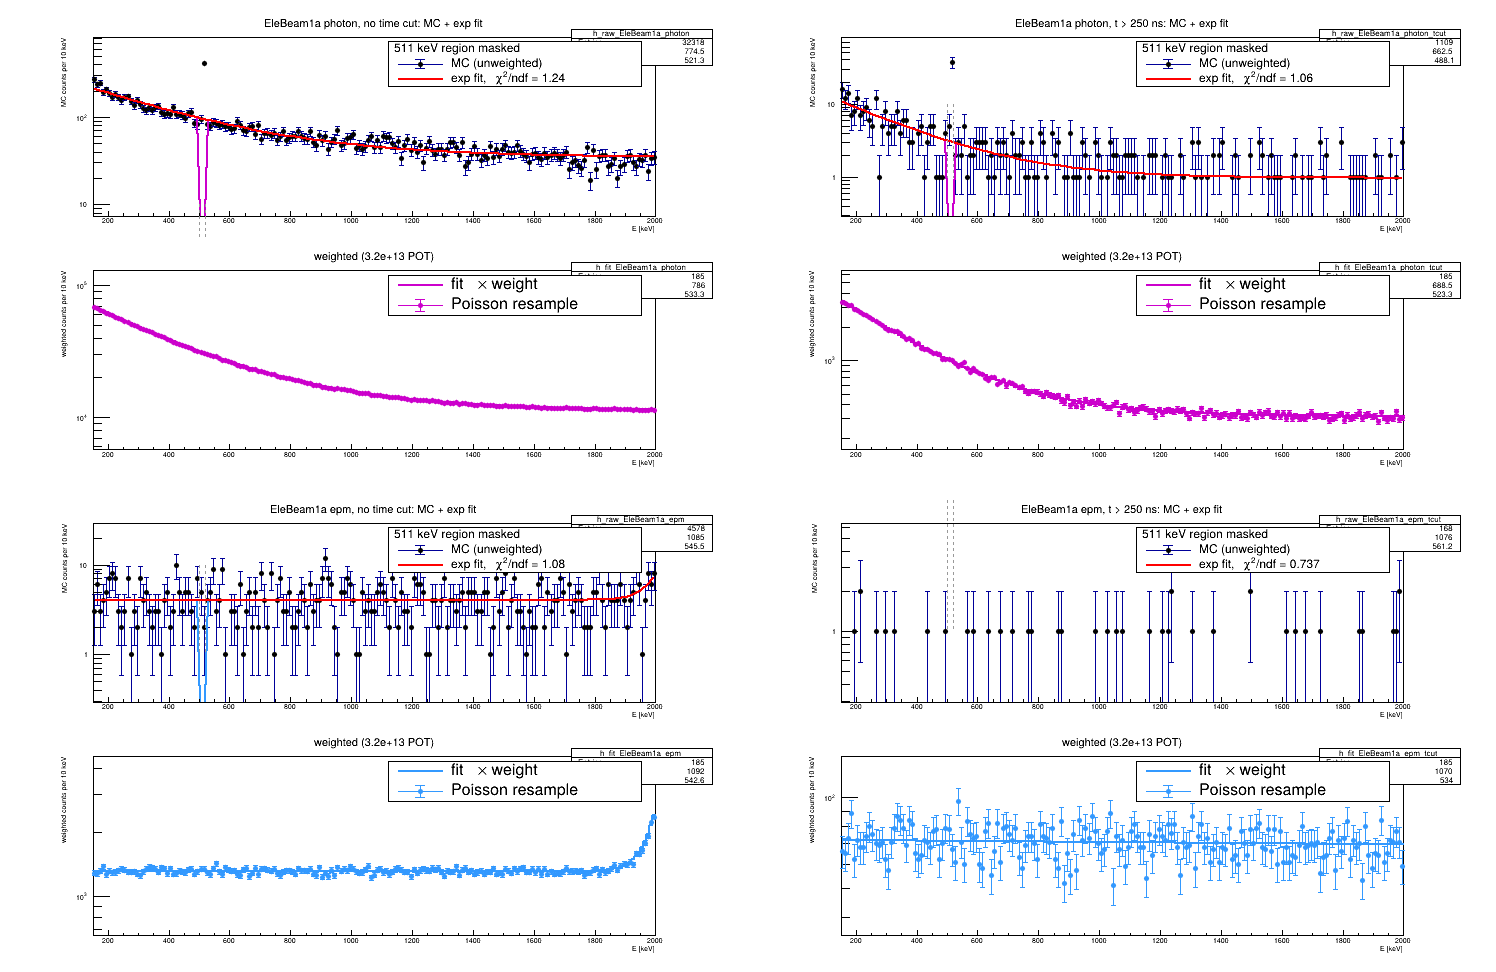

In [4]:
# deal with EleBeam1a first 
# due to the low stat, fit a exponetial to 150 keV - 2000 keV, excluding 500-520 keV
# later resampling uses the poisson smeared number from this fit
# separate photons and e+/-

fit_lo, fit_hi   = 150., 2000.
excl_lo, excl_hi = 500., 520.      # 511 annihilation peak, masked in the fit only
fit_binsize      = 10.
fit_nbins        = int((fit_hi-fit_lo)/fit_binsize)

ele_weight = event_dict["EleBeam1a"]["weight"]

# photons and e+/- treated as two separate groups
groups = {
    "photon": ([22],     ROOT.kMagenta+1),
    "epm":    ([11,-11], ROOT.kAzure+1),
}

# exponential with the 511 region rejected: TH1::Fit has no exclusion-range option,
# so the rejection lives in the fit function itself.
# Cling cannot redefine a function, so only declare it once per kernel session.
try:
    _expo_excl_declared
except NameError:
    ROOT.gInterpreter.Declare("""
    double expo_excl_cpp(double *x, double *par) {
        if (x[0] > %f && x[0] < %f) { TF1::RejectPoint(); return 0.; }
        return std::exp(par[0] + par[1]*x[0]) + par[2];
    }
    """ % (excl_lo, excl_hi))
    _expo_excl_declared = True

def fit_and_resample(tag, group_name, pids, extra_cut = None, seed = 20260807):
    """Unweighted spectrum -> exp fit (511 masked) -> weighted expectation -> per-bin Poisson."""
    v = event_dict[tag]
    pid_cut = "(" + " || ".join("pdgId == %d" % p for p in pids) + ")"

    rdf = ROOT.RDataFrame("Stage1virtualdetector/ttree", v["file"])
    rdf = rdf.Filter("virtualdetectorId == 101") \
             .Filter(pid_cut) \
             .Filter("pz > 0.") \
             .Define("Ek", "1000.*E") \
             .Define("dr", "sqrt((x-(%f))*(x-(%f)) + (y-(%f))*(y-(%f)))"
                     % (hole_X, hole_X, hole_Y, hole_Y)) \
             .Filter("dr < %f" % hole_radius)
    if extra_cut is not None:
        rdf = rdf.Filter(extra_cut)

    suffix = "%s_%s%s" % (tag, group_name, "_tcut" if extra_cut else "")

    # 1) raw MC counts, unweighted -- fit uncertainties then reflect true MC statistics
    h_raw = rdf.Histo1D((("h_raw_"+suffix),
                         "%s %s raw MC;E [keV];MC counts per %.0f keV" % (tag, group_name, fit_binsize),
                         fit_nbins, fit_lo, fit_hi), "Ek").GetValue()
    h_raw.SetDirectory(0)

    # 2) fit exponential over the full range with 500-520 keV rejected
    f = ROOT.TF1("f_"+suffix, ROOT.expo_excl_cpp, fit_lo, fit_hi, 3)
    f.SetParameters(np.log(max(h_raw.GetBinContent(1), 1.)), -1./500., 0.)
    f.SetLineColor(groups[group_name][1])

    res = h_raw.Fit(f, "RSQL")
    status = int(res) if res else -1
    ndf = f.GetNDF()
    print("%-22s N(MC)=%6d  chi2/ndf = %.4g/%d = %.3g  status=%d"
          % (suffix, int(h_raw.GetEntries()), f.GetChisquare(), ndf,
             f.GetChisquare()/ndf if ndf > 0 else np.nan, status))

    # full parameter listing: value +/- error, and the correlation between p0 and p1
    par_names = ["p0 (log norm)", "p1 (slope, 1/keV)", "p2 (pedestal)"]
    for ip in range(f.GetNpar()):
        print("    %-20s = %12.6g +/- %-12.6g" % (par_names[ip],
                                                  f.GetParameter(ip), f.GetParError(ip)))
    print("    %-20s = %12.6g keV" % ("1/e falloff", -1./f.GetParameter(1)
                                      if f.GetParameter(1) != 0 else np.nan))
    print("    %-20s = %12.6g" % ("corr(p0,p1)", res.Correlation(0, 1)))
    print("    %-20s = %12.6g" % ("fit prob", f.GetProb()))

    # 3+4) evaluate the fit across the FULL range (500-520 included), weight, Poisson smear.
    #      Weight is applied first; the error and the Poisson draw are taken on the
    #      weighted number, so fluctuations are those of the expected physical event count.
    h_fit  = h_raw.Clone("h_fit_"+suffix)     # fitted expectation, weighted
    h_samp = h_raw.Clone("h_samp_"+suffix)    # Poisson-smeared resample, weighted
    for h in (h_fit, h_samp):
        h.SetDirectory(0)
        h.Reset()
    rng_l = np.random.default_rng(seed)
    p0, p1, p2 = f.GetParameter(0), f.GetParameter(1), f.GetParameter(2)
    for ib in range(1, fit_nbins+1):
        # weight first, then take the error and the Poisson draw on the weighted number
        mu = (np.exp(p0 + p1*h_raw.GetBinCenter(ib))+p2)*ele_weight
        h_fit.SetBinContent(ib, mu)
        h_fit.SetBinError(ib, np.sqrt(mu))
        n = rng_l.poisson(mu)
        h_samp.SetBinContent(ib, n)
        h_samp.SetBinError(ib, np.sqrt(n))
        
    for h, col in ((h_fit, groups[group_name][1]), (h_samp, groups[group_name][1])):
        h.SetLineColor(col)
    h_samp.SetMarkerStyle(20)
    h_samp.SetMarkerSize(0.6)
    h_samp.SetMarkerColor(groups[group_name][1])
    h_fit.SetLineWidth(2)

    print("%-22s integral: raw(MC)=%.4g  fit(weighted)=%.4g  resampled(weighted)=%.4g"
          % (suffix, h_raw.Integral(), h_fit.Integral(), h_samp.Integral()))
    return {"raw": h_raw, "f": f, "fit": h_fit, "samp": h_samp}

# no time cut, then repeating with time cut t>250 ns
ele_fits = {}
for group_name, (pids, _) in groups.items():
    ele_fits[(group_name, "all")]  = fit_and_resample("EleBeam1a", group_name, pids)
    ele_fits[(group_name, "tcut")] = fit_and_resample("EleBeam1a", group_name, pids,
                                                      extra_cut = "time > 250.")

# draw: rows = photon / e+-, cols = no time cut / t>250 ns
# top of each pad: raw MC spectrum + fitted exponential (the fit itself)
# bottom: weighted expectation + Poisson resample
cEle = ROOT.TCanvas("cEle", "cEle", 1500, 1000)
cEle.Divide(2, 2)
keep = []            # keep TLine/TLegend/TF1 clones alive past the loop
ipad = 0
for group_name in groups:
    for tsel, tlabel in (("all", "no time cut"), ("tcut", "t > 250 ns")):
        ipad += 1
        pad = cEle.cd(ipad)
        pad.Divide(1, 2)

        d = ele_fits[(group_name, tsel)]

        # --- upper: the fit, over the unweighted MC it was fitted to ---
        pad.cd(1)
        gPad.SetLogy()
        d["raw"].SetTitle("EleBeam1a %s, %s: MC + exp fit;E [keV];MC counts per %.0f keV"
                          % (group_name, tlabel, fit_binsize))
        d["raw"].SetMarkerStyle(20)
        d["raw"].SetMarkerSize(0.5)
        d["raw"].Draw("e1")

        # the fitted TF1 rejects 500-520, so draw a clean continuum curve across the full
        # range to show the extrapolation through the masked region
        fdraw = ROOT.TF1("fdraw_%s_%s" % (group_name, tsel), "expo(0)+[2]", fit_lo, fit_hi)
        fdraw.SetParameters(d["f"].GetParameter(0), d["f"].GetParameter(1),
                            d["f"].GetParameter(2))
        fdraw.SetLineColor(ROOT.kRed)
        fdraw.SetLineWidth(2)
        fdraw.Draw("same")
        keep.append(fdraw)

        # shade the masked 511 window
        ymin, ymax = gPad.GetUymin(), gPad.GetUymax()
        for xe in (excl_lo, excl_hi):
            ln = ROOT.TLine(xe, 10**ymin, xe, 10**ymax)
            ln.SetLineColor(ROOT.kGray+1)
            ln.SetLineStyle(2)
            ln.Draw()
            keep.append(ln)

        ndf = d["f"].GetNDF()
        leg1 = ROOT.TLegend(0.52, 0.68, 0.88, 0.88)
        leg1.AddEntry(d["raw"], "MC (unweighted)", "lep")
        leg1.AddEntry(fdraw, "exp fit, #chi^{2}/ndf = %.3g" %
                      (d["f"].GetChisquare()/ndf if ndf > 0 else np.nan), "l")
        leg1.SetHeader("511 keV region masked")
        leg1.Draw()
        keep.append(leg1)

        # --- lower: weighted expectation + Poisson resample ---
        pad.cd(2)
        gPad.SetLogy()
        d["fit"].SetTitle("weighted (%.2g POT);E [keV];weighted counts per %.0f keV"
                          % (nPOT, fit_binsize))
        d["fit"].Draw("hist")
        d["samp"].Draw("e1 same")
        leg2 = ROOT.TLegend(0.52, 0.70, 0.88, 0.88)
        leg2.AddEntry(d["fit"],  "fit #times weight", "l")
        leg2.AddEntry(d["samp"], "Poisson resample", "lep")
        leg2.Draw()
        keep.append(leg2)

cEle.Draw()

In [5]:
# add background to the THStack. MuBeam1a (and Neutrals1a) come straight from MC;
# EleBeam1a is replaced by the exponential fit + Poisson resample built earlier, since
# its raw MC has too few entries in this window to stack directly.
# Repeated for both time selections: rows = no time cut / t > 250 ns,
# columns = by source / by particle.
mc_tags     = ["MuBeam1a"]#, "Neutrals1a"]
bkgd_tags   = mc_tags + ["EleBeam1a"]
stack_order = ["EleBeam1a"] + mc_tags          # bottom-to-top in the stack
tag_colors  = {"MuBeam1a": ROOT.kAzure+1, "EleBeam1a": ROOT.kOrange+1, "Neutrals1a": ROOT.kGreen+2}

# two particle categories, matching the groups the Ele fit was done in
grp_list   = ["epm", "photon"]
grp_pids   = {"epm": [11, -11], "photon": [22]}
grp_colors = {"epm": ROOT.kTeal+2, "photon": ROOT.kBlue+1}
grp_names  = {"epm": "e^{#pm}", "photon": "#gamma"}
pdgId_cut  = "(pdgId == 22 || pdgId == 11 || pdgId == -11)"

# time selections: rows of the final 2x2. 91% of the 1809 signal survives t > 250 ns.
sgnl_eff  = {"all": 1.00, "tcut": 0.91}
tsel_list = [("all",  None,          "no time cut"),
             ("tcut", "time > 250.", "t > 250 ns")]

labr_sigma = 15.0

344 all   MuBeam1a     entries:   2996, weighted: 1.273e+04
344 all   EleBeam1a    from fit, weighted: 5.423e+05
344 tcut  MuBeam1a     entries:   1998, weighted: 9460
344 tcut  EleBeam1a    from fit, weighted: 2.124e+04
344 all   (no time cut): B by source = 555052, B by particle = 555052
344 tcut  (t > 250 ns): B by source = 30704, B by particle = 30704


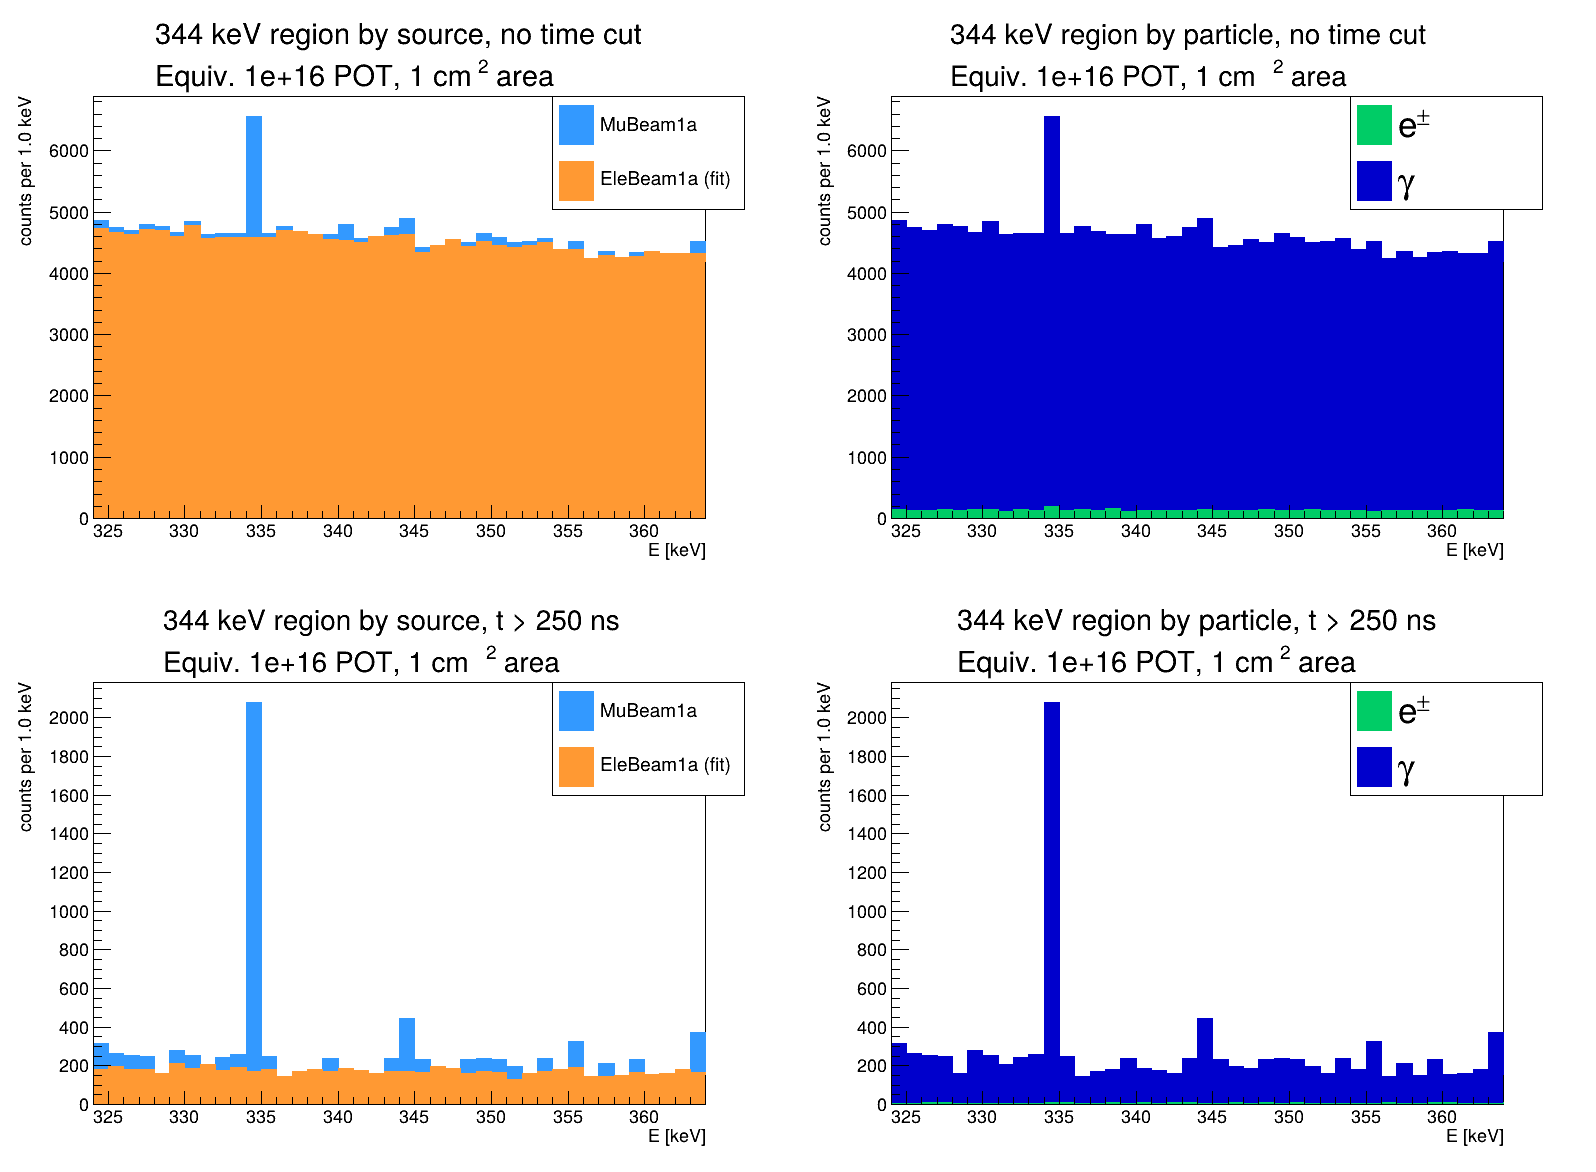

In [6]:
# ---- 344 keV gamma, run1a background only (no signal component) ----
# Same construction as the 1809 plot, but repeated for both Ele time selections:
# rows = no time cut / t > 250 ns, columns = by source / by particle.
E_344      = 344.
halfwin344 = 60.
nbins344   = 120
binsize344 = 2.*halfwin344/nbins344
lo344, hi344 = E_344-halfwin344, E_344+halfwin344
halfwinshow = 20.
loshow, hishow = E_344-halfwinshow, E_344+halfwinshow

# bottom-to-top order in the stack
stack_order = ["EleBeam1a"] + mc_tags

# time cut applied to the MC components, matching the Ele fit's "tcut" selection
tsel_list = [("all",  None,          "no time cut"),
             ("tcut", "time > 250.", "t > 250 ns")]

def book344(name, title):
    return ((name, title+";E [keV];counts per %.1f keV" % binsize344,
             nbins344, lo344, hi344), "Ek")

def ele_from_fit344(name, group_name, tsel, color, rng_l):
    """Evaluate the fitted Ele continuum on the 344 binning and Poisson-smear it."""
    d = ele_fits[(group_name, tsel)]
    f = d["f"]
    p0, p1, p2 = f.GetParameter(0), f.GetParameter(1), f.GetParameter(2)
    h = ROOT.TH1D(name, "EleBeam1a %s (fit);E [keV];counts per %.1f keV" % (group_name, binsize344),
                  nbins344, lo344, hi344)
    h.SetDirectory(0)
    for ib in range(1, nbins344+1):
        # fit normalization is per fit_binsize; rescale to this bin width
        mu = (np.exp(p0 + p1*h.GetBinCenter(ib)) + p2)*ele_weight*(binsize344/fit_binsize)
        mu = max(mu, 0.)
        n = rng_l.poisson(mu)
        h.SetBinContent(ib, n)
        h.SetBinError(ib, np.sqrt(n))
    h.SetFillColor(color)
    h.SetLineColor(color)
    return h

# build both time selections
h344_bytag = {}   # (tsel, tag)   -> TH1D
h344_bygrp = {}   # (tsel, group) -> TH1D

for tsel, tcut, tlabel in tsel_list:
    rng_l = np.random.default_rng(31415)   # same seed per selection: differences are the fit, not the throw

    # --- MC components ---
    for tag in mc_tags:
        v = event_dict[tag]
        rdf = ROOT.RDataFrame("Stage1virtualdetector/ttree", v["file"])
        rdf = rdf.Filter("virtualdetectorId == 101") \
                 .Filter(pdgId_cut) \
                 .Filter("pz > 0.") \
                 .Define("Ek", "1000.*E") \
                 .Define("dr", "sqrt((x-(%f))*(x-(%f)) + (y-(%f))*(y-(%f)))"
                         % (hole_X, hole_X, hole_Y, hole_Y)) \
                 .Filter("dr < %f" % hole_radius)
        if tcut is not None:
            rdf = rdf.Filter(tcut)

        ptr_tag = rdf.Histo1D(*book344("h344_%s_%s" % (tsel, tag), tag))
        ptrs_grp = {}
        for g in grp_list:
            gcut = "(" + " || ".join("pdgId == %d" % p for p in grp_pids[g]) + ")"
            ptrs_grp[g] = rdf.Filter(gcut).Histo1D(
                *book344("h344_%s_%s_%s" % (tsel, tag, g), grp_names[g]))

        h = ptr_tag.GetValue()
        h.SetDirectory(0)
        h.Scale(v["weight"])
        h.SetFillColor(tag_colors[tag])
        h.SetLineColor(tag_colors[tag])
        h344_bytag[(tsel, tag)] = h
        print("344 %-5s %-12s entries: %6d, weighted: %.4g"
              % (tsel, tag, h.GetEntries(), h.Integral()))

        for g, ptr in ptrs_grp.items():
            hp = ptr.GetValue()
            hp.SetDirectory(0)
            hp.Scale(v["weight"])
            key = (tsel, g)
            if key not in h344_bygrp:
                hp.SetName("h344_%s_grp_%s" % (tsel, g))
                hp.SetFillColor(grp_colors[g])
                hp.SetLineColor(grp_colors[g])
                h344_bygrp[key] = hp
            else:
                h344_bygrp[key].Add(hp)

    # --- EleBeam1a from the fit for this time selection ---
    ele_grp = {g: ele_from_fit344("h344_%s_ele_%s" % (tsel, g), g, tsel, grp_colors[g], rng_l)
               for g in grp_list}

    h_ele = ele_grp["photon"].Clone("h344_%s_EleBeam1a" % tsel)
    h_ele.SetDirectory(0)
    h_ele.Add(ele_grp["epm"])
    h_ele.SetFillColor(tag_colors["EleBeam1a"])
    h_ele.SetLineColor(tag_colors["EleBeam1a"])
    h344_bytag[(tsel, "EleBeam1a")] = h_ele
    print("344 %-5s %-12s from fit, weighted: %.4g" % (tsel, "EleBeam1a", h_ele.Integral()))

    for g in grp_list:
        add = ele_grp[g].Clone("h344_%s_eleadd_%s" % (tsel, g))
        add.SetDirectory(0)
        key = (tsel, g)
        if key not in h344_bygrp:
            add.SetName("h344_%s_grp_%s" % (tsel, g))
            add.SetFillColor(grp_colors[g])
            add.SetLineColor(grp_colors[g])
            h344_bygrp[key] = add
        else:
            h344_bygrp[key].Add(add)

# ---- draw: 2 rows (time selection) x 2 cols (by source / by particle) ----
hdummy = ROOT.TH1F("hdummy", "Title", 100, loshow, hishow)
hdummy.SetStats(0)
c344 = ROOT.TCanvas("c344", "c344", 1600, 1200)
c344.Divide(2, 2)
keep344 = []
ipad = 0

for tsel, tcut, tlabel in tsel_list:
    # left: by source
    ipad += 1
    thispad = c344.cd(ipad)
    thispad.SetTopMargin(0.15)
    hs = ROOT.THStack("hs344_tag_%s" % tsel,
                      "#splitline{344 keV region by source, %s}{Equiv. %.2g POT, 1 cm{}^{2} area};E [keV];counts per %.1f keV"
                      % (tlabel, nNorm, binsize344))
    for tag in stack_order:
        hs.Add(h344_bytag[(tsel, tag)])
    hs.SetHistogram(hdummy)
    hs.Draw("hist")
    leg = ROOT.TLegend(0.70, 0.65, 0.95, 0.85)
    for tag in reversed(stack_order):
        label = tag
        if tag == "EleBeam1a":
            label += " (fit)"
        leg.AddEntry(h344_bytag[(tsel, tag)], label, "f")
    leg.Draw()
    keep344 += [hs, leg]

    # right: by particle
    ipad += 1
    thispad = c344.cd(ipad)
    thispad.SetTopMargin(0.15)
    hsg = ROOT.THStack("hs344_grp_%s" % tsel,
                       "#splitline{344 keV region by particle, %s}{Equiv. %.2g POT, 1 cm{}^{2} area};E [keV];counts per %.1f keV"
                       % (tlabel, nNorm, binsize344))
    for g in grp_list:
        hsg.Add(h344_bygrp[(tsel, g)])
    hsg.SetHistogram(hdummy)
    hsg.Draw("hist")
    legg = ROOT.TLegend(0.70, 0.65, 0.95, 0.85)
    for g in grp_list:
        legg.AddEntry(h344_bygrp[(tsel, g)], grp_names[g], "f")
    # legg.SetHeader(tlabel)
    legg.Draw()
    keep344 += [hsg, legg]

c344.Draw()

for tsel, tcut, tlabel in tsel_list:
    nB_tag = sum(h344_bytag[(tsel, t)].Integral() for t in bkgd_tags)
    nB_grp = sum(h344_bygrp[(tsel, g)].Integral() for g in grp_list)
    print("344 %-5s (%s): B by source = %.6g, B by particle = %.6g"
          % (tsel, tlabel, nB_tag, nB_grp))

0 entries of e+/- in the target range
MuBeam1a gamma local fit (excess masked): N(MC)=1820  chi2/ndf = 138.2/116 = 1.19
    p0 (log norm)        =      23.1637 +/- 9.01906     
    p1 (slope, 1/keV)    =   -0.0824703 +/- 0.0311353   
    p2 (pedestal)        =     0.854085 +/- 0.0973561   
bin [334, 335): observed = 28, continuum = 0.8661, excess = 27.13 (MC counts)
signal events at 31830000000000 POT = 1847
HPGe   smeared: integral = 1847, peak bin = 508.2
LaBr3  smeared: integral = 1847, peak bin = 58.02


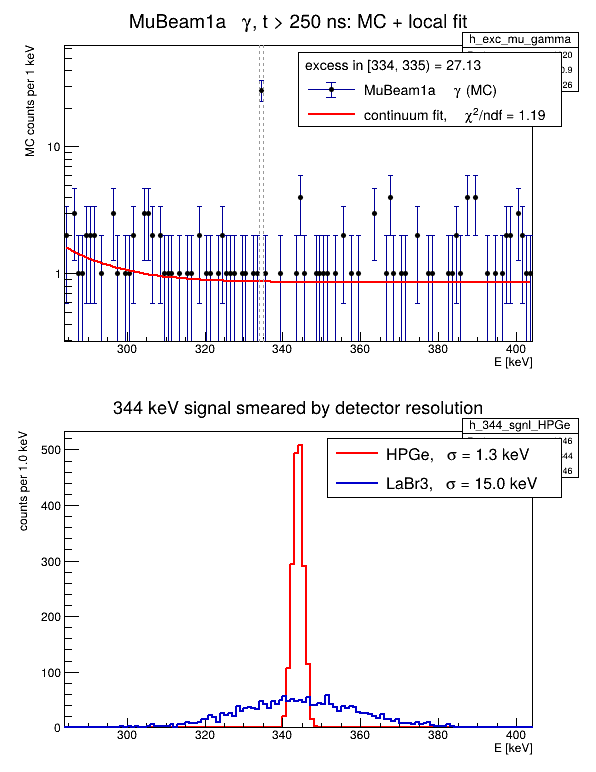

In [7]:
# fit the excess in bin [334, 335) (for MuBeam1a and gamma), and treat that number as the
# number of singal events. draw smearing with both detector resolution. center the signal
# peak at 344 keV. Both MuBeam1a groups are fit locally here: the gamma continuum with the
# excess bin masked (so the peak is excluded by construction), and e+/- unmasked.

# At 344 keV slightly better resolution
E_sigma = 1.3

# the excess bin, as written in the comment -- note it is not centered on 344
excess_lo, excess_hi = 334., 335.
E_344_peak = 344.          # where the smeared signal peak is placed

# fine binning so the excess bin is resolved on its own; range matches the stack window
exc_lo, exc_hi = E_344_peak-60., E_344_peak+60.      # 284 - 404 keV
exc_binsize    = 1.
exc_nbins      = int((exc_hi-exc_lo)/exc_binsize)

# ---- MuBeam1a, fine-binned around the line, per particle group ----
v = event_dict["MuBeam1a"]

def mu_local_rdf(pids):
    pid_cut = "(" + " || ".join("pdgId == %d" % p for p in pids) + ")"
    return ROOT.RDataFrame("Stage1virtualdetector/ttree", v["file"]) \
               .Filter("virtualdetectorId == 101") \
               .Filter(pid_cut) \
               .Filter("pz > 0.") \
               .Define("Ek", "1000.*E") \
               .Define("dr", "sqrt((x-(%f))*(x-(%f)) + (y-(%f))*(y-(%f)))"
                       % (hole_X, hole_X, hole_Y, hole_Y)) \
               .Filter("dr < %f" % hole_radius) \
               .Filter("time > 250.")

h_exc = mu_local_rdf([22]).Histo1D(("h_exc_mu_gamma",
                     "MuBeam1a #gamma;E [keV];MC counts per %.0f keV" % exc_binsize,
                     exc_nbins, exc_lo, exc_hi), "Ek").GetValue()
h_exc.SetDirectory(0)

h_exc_epm = mu_local_rdf(grp_pids["epm"]).Histo1D(("h_exc_mu_epm",
                     "MuBeam1a e^{#pm};E [keV];MC counts per %.0f keV" % exc_binsize,
                     exc_nbins, exc_lo, exc_hi), "Ek").GetValue()
h_exc_epm.SetDirectory(0)
print("%i entries of e+/- in the target range"%h_exc_epm.Integral())

# ---- continuum fit, excluding the excess bin, to get the excess above background ----
# reuse the same masked-exponential trick: mask the excess bin, fit the continuum around it
try:
    _expo_excl_exc_declared
except NameError:
    ROOT.gInterpreter.Declare("""
    double expo_excl_exc_cpp(double *x, double *par) {
        if (x[0] > %f && x[0] < %f) { TF1::RejectPoint(); return 0.; }
        return std::exp(par[0] + par[1]*x[0]) + par[2];
    }
    """ % (excess_lo, excess_hi))
    _expo_excl_exc_declared = True

f_exc = ROOT.TF1("f_exc", ROOT.expo_excl_exc_cpp, exc_lo, exc_hi, 3)
f_exc.SetParameters(np.log(max(h_exc.GetBinContent(1), 1.)), -1./500., 0.)
res_exc = h_exc.Fit(f_exc, "RSQL")
ndf_exc = f_exc.GetNDF()
print("MuBeam1a gamma local fit (excess masked): N(MC)=%d  chi2/ndf = %.4g/%d = %.3g"
      % (int(h_exc.GetEntries()), f_exc.GetChisquare(), ndf_exc,
         f_exc.GetChisquare()/ndf_exc if ndf_exc > 0 else np.nan))
for ip, nm in enumerate(["p0 (log norm)", "p1 (slope, 1/keV)", "p2 (pedestal)"]):
    print("    %-20s = %12.6g +/- %-12.6g" % (nm, f_exc.GetParameter(ip), f_exc.GetParError(ip)))

# local MuBeam1a continuum fits, keyed like ele_fits for use downstream
mu_local = {"photon": f_exc}

# observed minus fitted continuum, in the excess bin
ib_exc   = h_exc.FindBin(0.5*(excess_lo+excess_hi))
n_obs    = h_exc.GetBinContent(ib_exc)
p0, p1, p2 = (f_exc.GetParameter(i) for i in range(3))
n_cont   = np.exp(p0 + p1*h_exc.GetBinCenter(ib_exc)) + p2
n_excess = max(n_obs - n_cont, 0.)
print("bin [%.0f, %.0f): observed = %.4g, continuum = %.4g, excess = %.4g (MC counts)"
      % (excess_lo, excess_hi, n_obs, n_cont, n_excess))

# treat the excess as the signal, weighted to nPOT
nSgnl_344 = n_excess*v["weight"]
print("signal events at %.0f POT = %.4g" % (nPOT, nSgnl_344))

# ---- smear that number with both detector resolutions, centered at 344 keV ----
resolutions = [("HPGe",  E_sigma,    ROOT.kRed),
               ("LaBr3", labr_sigma, ROOT.kBlue+1)]

# window wide enough for the 15 keV sigma case
sm_halfwin = 60.
sm_binsize = 1.
sm_nbins   = int(2.*sm_halfwin/sm_binsize)
sm_lo, sm_hi = E_344_peak-sm_halfwin, E_344_peak+sm_halfwin

h_smeared = {}
rng_sm = np.random.default_rng(2718)
for name, sigma, color in resolutions:
    h = ROOT.TH1D("h_344_sgnl_%s" % name,
                  "344 keV signal, %s (#sigma = %.1f keV);E [keV];counts per %.1f keV"
                  % (name, sigma, sm_binsize),
                  sm_nbins, sm_lo, sm_hi)
    h.SetDirectory(0)
    nThrow_sm = int(min(max(nSgnl_344, 1.), 1000000))
    sm_scale  = nSgnl_344/float(nThrow_sm)
    for E in rng_sm.normal(E_344_peak, sigma, nThrow_sm):
        h.Fill(E)
    h.Scale(sm_scale)
    h.SetLineColor(color)
    h.SetLineWidth(2)
    h.SetFillStyle(0)
    h_smeared[name] = h
    print("%-6s smeared: integral = %.4g, peak bin = %.4g"
          % (name, h.Integral(), h.GetMaximum()))

# ---- draw: both MuBeam1a local fits, and the two smeared signals ----
cExc = ROOT.TCanvas("cExc", "cExc", 600, 800)
cExc.Divide(1, 2)
keepExc = []

# pad 1+2: the two local continuum fits, over the MC they were fit to
fit_pads = [(1, h_exc,     f_exc,     "#gamma",    True)]

for ipad, hmc, ffit, glabel, masked in fit_pads:
    cExc.cd(ipad)
    gPad.SetLogy()
    hmc.SetTitle("MuBeam1a %s, t > 250 ns: MC + local fit;E [keV];MC counts per %.0f keV"
                 % (glabel, exc_binsize))
    hmc.SetMarkerStyle(20)
    hmc.SetMarkerSize(0.5)
    hmc.Draw("e1")

    # the masked TF1 returns 0 inside the excess window, so draw a clean continuum
    # carrying the same fitted parameters straight through it
    fdraw = ROOT.TF1("fdraw_exc_%d" % ipad, "expo(0)+[2]", exc_lo, exc_hi)
    fdraw.SetParameters(ffit.GetParameter(0), ffit.GetParameter(1), ffit.GetParameter(2))
    fdraw.SetLineColor(ROOT.kRed)
    fdraw.SetLineWidth(2)
    fdraw.Draw("same")
    keepExc.append(fdraw)

    ndf_ = ffit.GetNDF()
    leg = ROOT.TLegend(0.50, 0.68, 0.95, 0.88)
    leg.AddEntry(hmc, "MuBeam1a %s (MC)" % glabel, "lep")
    leg.AddEntry(fdraw, "continuum fit, #chi^{2}/ndf = %.3g"
                 % (ffit.GetChisquare()/ndf_ if ndf_ > 0 else np.nan), "l")
    if masked:
        # mark the masked window and report the excess it contains
        gPad.Update()
        for xe in (excess_lo, excess_hi):
            ln = ROOT.TLine(xe, 10**gPad.GetUymin(), xe, 10**gPad.GetUymax())
            ln.SetLineColor(ROOT.kGray+1)
            ln.SetLineStyle(2)
            ln.Draw()
            keepExc.append(ln)
        leg.SetHeader("excess in [%.0f, %.0f) = %.4g" % (excess_lo, excess_hi, n_excess))
    else:
        leg.SetHeader("no mask (excess is a photon line)")
    leg.Draw()
    keepExc.append(leg)

# pad 2: the smeared signals
cExc.cd(2)
first = True
for name, sigma, color in resolutions:
    h_smeared[name].SetTitle("344 keV signal smeared by detector resolution;E [keV];counts per %.1f keV"
                             % sm_binsize)
    h_smeared[name].Draw("hist" if first else "hist same")
    first = False
leg_sm = ROOT.TLegend(0.55, 0.72, 0.95, 0.88)
for name, sigma, color in resolutions:
    leg_sm.AddEntry(h_smeared[name], "%s, #sigma = %.1f keV" % (name, sigma), "l")
leg_sm.Draw()
keepExc.append(leg_sm)

cExc.Draw()

excess removed from background: 1847 weighted counts
HPGe   signal on stack grid: 1847 of 1847
LaBr3  signal on stack grid: 1847 of 1847
HPGe  : S = 1847, B (peak removed) = 2.886e+04, S/B = 0.06399, S/sqrt(B) = 10.87
LaBr3 : S = 1847, B (peak removed) = 2.886e+04, S/B = 0.06399, S/sqrt(B) = 10.87


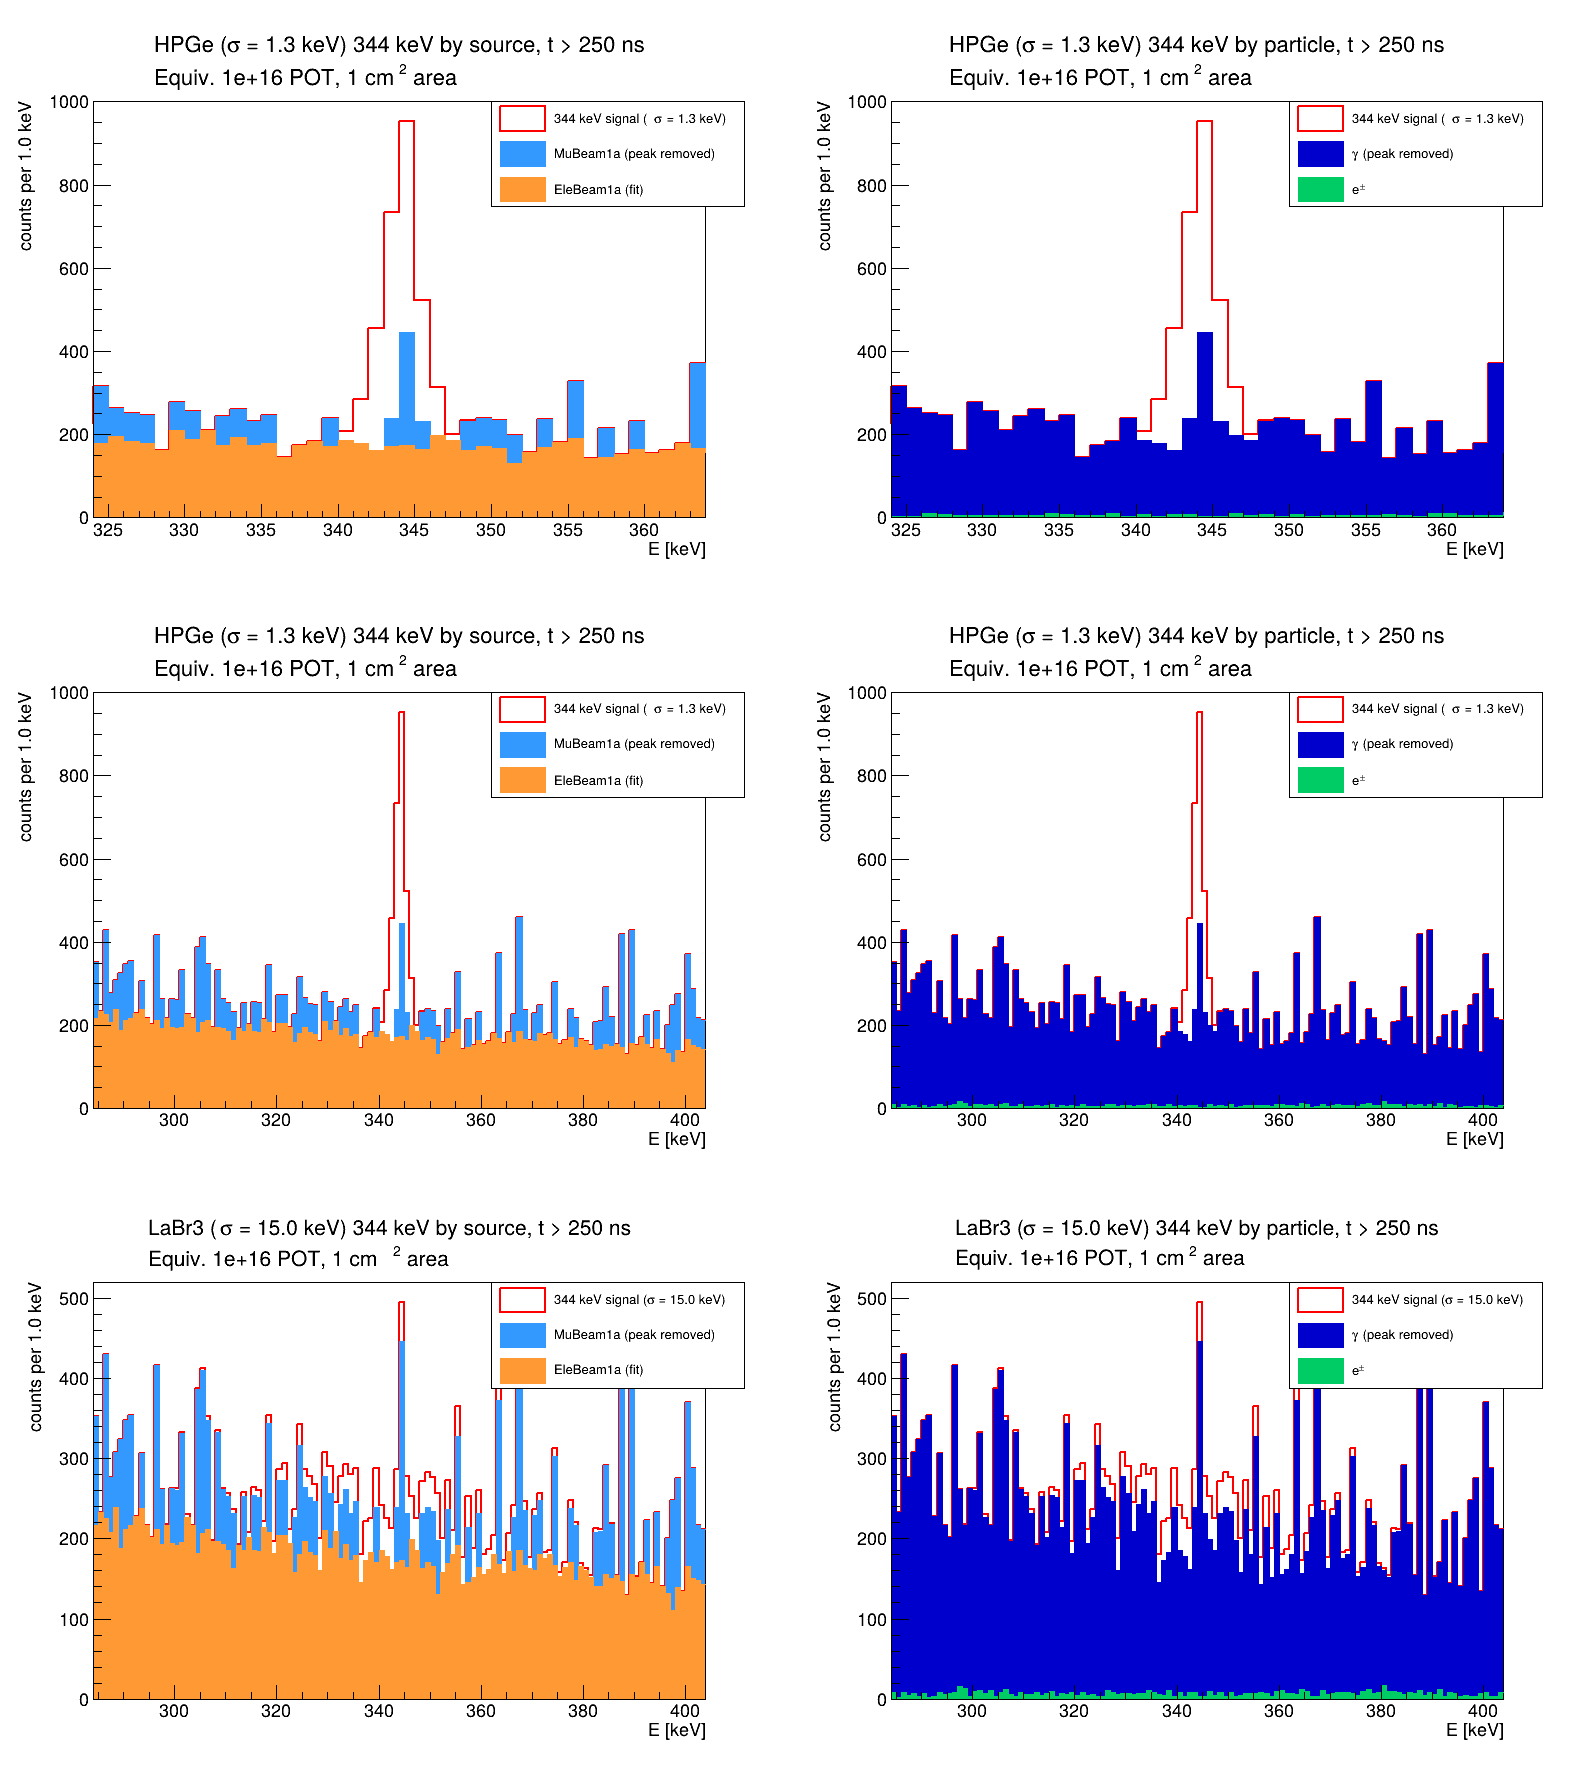

In [8]:
# ---- 344 keV, t > 250 ns: excess taken out of the background, added back smeared ----
# The 344 stacks are reused by both rows
# Left: excess removed from MuBeam1a. Right: removed from the gamma group.
# Same events either way -- two different decompositions of the same background.

tsel_sig = "tcut"
n_excess_w = n_excess*event_dict["MuBeam1a"]["weight"]
print("excess removed from background: %.4g weighted counts" % n_excess_w)

def strip_excess(h, n_removed, newname):
    """Copy of h with n_removed counts taken out of the bin holding the excess."""
    hc = h.Clone(newname)
    hc.SetDirectory(0)
    ib = hc.FindBin(0.5*(excess_lo+excess_hi))
    hc.SetBinContent(ib, max(hc.GetBinContent(ib) - n_removed, 0.))
    return hc

def regrid(src, name, color):
    """Put a smeared signal histogram onto the 344 stack binning."""
    h = ROOT.TH1D(name, "344 keV signal;E [keV];counts per %.1f keV" % binsize344,
                  nbins344, lo344, hi344)
    h.SetDirectory(0)
    for ib in range(1, src.GetNbinsX()+1):
        jb = h.FindBin(src.GetBinCenter(ib))
        if 1 <= jb <= nbins344:
            h.AddBinContent(jb, src.GetBinContent(ib))
    h.SetLineColor(color)
    h.SetLineWidth(2)
    return h

sig_by_det = {det: regrid(h_smeared[det], "h_sig344_%s" % det, ROOT.kRed)
              for det in ("HPGe", "LaBr3")}
for det in ("HPGe", "LaBr3"):
    print("%-6s signal on stack grid: %.4g of %.4g"
          % (det, sig_by_det[det].Integral(), h_smeared[det].Integral()))

# ---- draw: rows = detector resolution, cols = by source / by particle ----
cSig = ROOT.TCanvas("cSig", "cSig", 1600, 1800)
cSig.Divide(2, 3)
keepSig = []
ipad = 0

for ii, det, sigma in ((0, "HPGe", E_sigma), (1, "HPGe", E_sigma), (2, "LaBr3", labr_sigma)):
    sig = sig_by_det[det]
    slabel = "344 keV signal (#sigma = %.1f keV)" % sigma

    # ---- left: by source, excess removed from MuBeam1a ----
    ipad += 1
    thispad = cSig.cd(ipad)
    thispad.SetTopMargin(0.15)
    hs = ROOT.THStack("hs_sig344_tag_%s" % det,
                      "#splitline{%s (#sigma = %.1f keV) 344 keV by source, t > 250 ns}{Equiv. %.2g POT, 1 cm{}^{2} area};E [keV];counts per %.1f keV"
                      % (det, sigma, nNorm, binsize344))
    th = {}
    for tag in stack_order:
        h = h344_bytag[(tsel_sig, tag)]
        if tag == "MuBeam1a":
            h = strip_excess(h, n_excess_w, "h_sig344_%s_mu_nopk" % det)
            keepSig.append(h)
        th[tag] = h
        hs.Add(h)
    hs.Add(sig)
    if ii == 0: 
        hs.SetHistogram(hdummy)
    hs.Draw("hist")
    leg = ROOT.TLegend(0.62, 0.66, 0.95, 0.85)
    leg.AddEntry(sig, slabel, "f")
    for tag in reversed(stack_order):
        label = tag + (" (fit)" if tag == "EleBeam1a" else " (peak removed)")
        leg.AddEntry(th[tag], label, "f")
    leg.Draw()
    keepSig += [hs, leg]

    # ---- right: by particle, excess removed from gamma ----
    ipad += 1
    thispad = cSig.cd(ipad)
    thispad.SetTopMargin(0.15)
    hsg = ROOT.THStack("hs_sig344_grp_%s" % det,
                       "#splitline{%s (#sigma = %.1f keV) 344 keV by particle, t > 250 ns}{Equiv. %.2g POT, 1 cm{}^{2} area};E [keV];counts per %.1f keV"
                       % (det, sigma, nNorm, binsize344))
    gh = {}
    for g in grp_list:
        h = h344_bygrp[(tsel_sig, g)]
        if g == "photon":
            h = strip_excess(h, n_excess_w, "h_sig344_%s_gam_nopk" % det)
            keepSig.append(h)
        gh[g] = h
        hsg.Add(h)
    hsg.Add(sig)
    if ii == 0: 
        hsg.SetHistogram(hdummy)
    hsg.Draw("hist")
    legg = ROOT.TLegend(0.62, 0.66, 0.95, 0.85)
    legg.AddEntry(sig, slabel, "f")
    for g in reversed(grp_list):
        label = grp_names[g] + (" (peak removed)" if g == "photon" else "")
        legg.AddEntry(gh[g], label, "f")
    legg.Draw()
    keepSig += [hsg, legg]

cSig.Draw()

for det, sigma in (("HPGe", E_sigma), ("LaBr3", labr_sigma)):
    nS = sig_by_det[det].Integral()
    nB = sum(h344_bytag[(tsel_sig, t)].Integral() for t in stack_order) - n_excess_w
    print("%-6s: S = %.4g, B (peak removed) = %.4g, S/B = %.4g, S/sqrt(B) = %.4g"
          % (det, nS, nB, nS/nB if nB > 0 else np.inf, nS/np.sqrt(nB) if nB > 0 else np.inf))

MuBeam1a epm: no local fit (no MC entries in window), contributing zero
MuBeam1a from local fit, weighted: 7599
epm      total weighted: 897
photon   total weighted: 2.818e+04
HPGe   signal on grid: 1847 of 1847
LaBr3  signal on grid: 1847 of 1847
HPGe  : S = 1847, B = 2.908e+04, S/B = 0.06351, S/sqrt(B) = 10.83
        cross-check: B by source = 29077, B by particle = 29077
LaBr3 : S = 1847, B = 2.908e+04, S/B = 0.06351, S/sqrt(B) = 10.83
        cross-check: B by source = 29077, B by particle = 29077


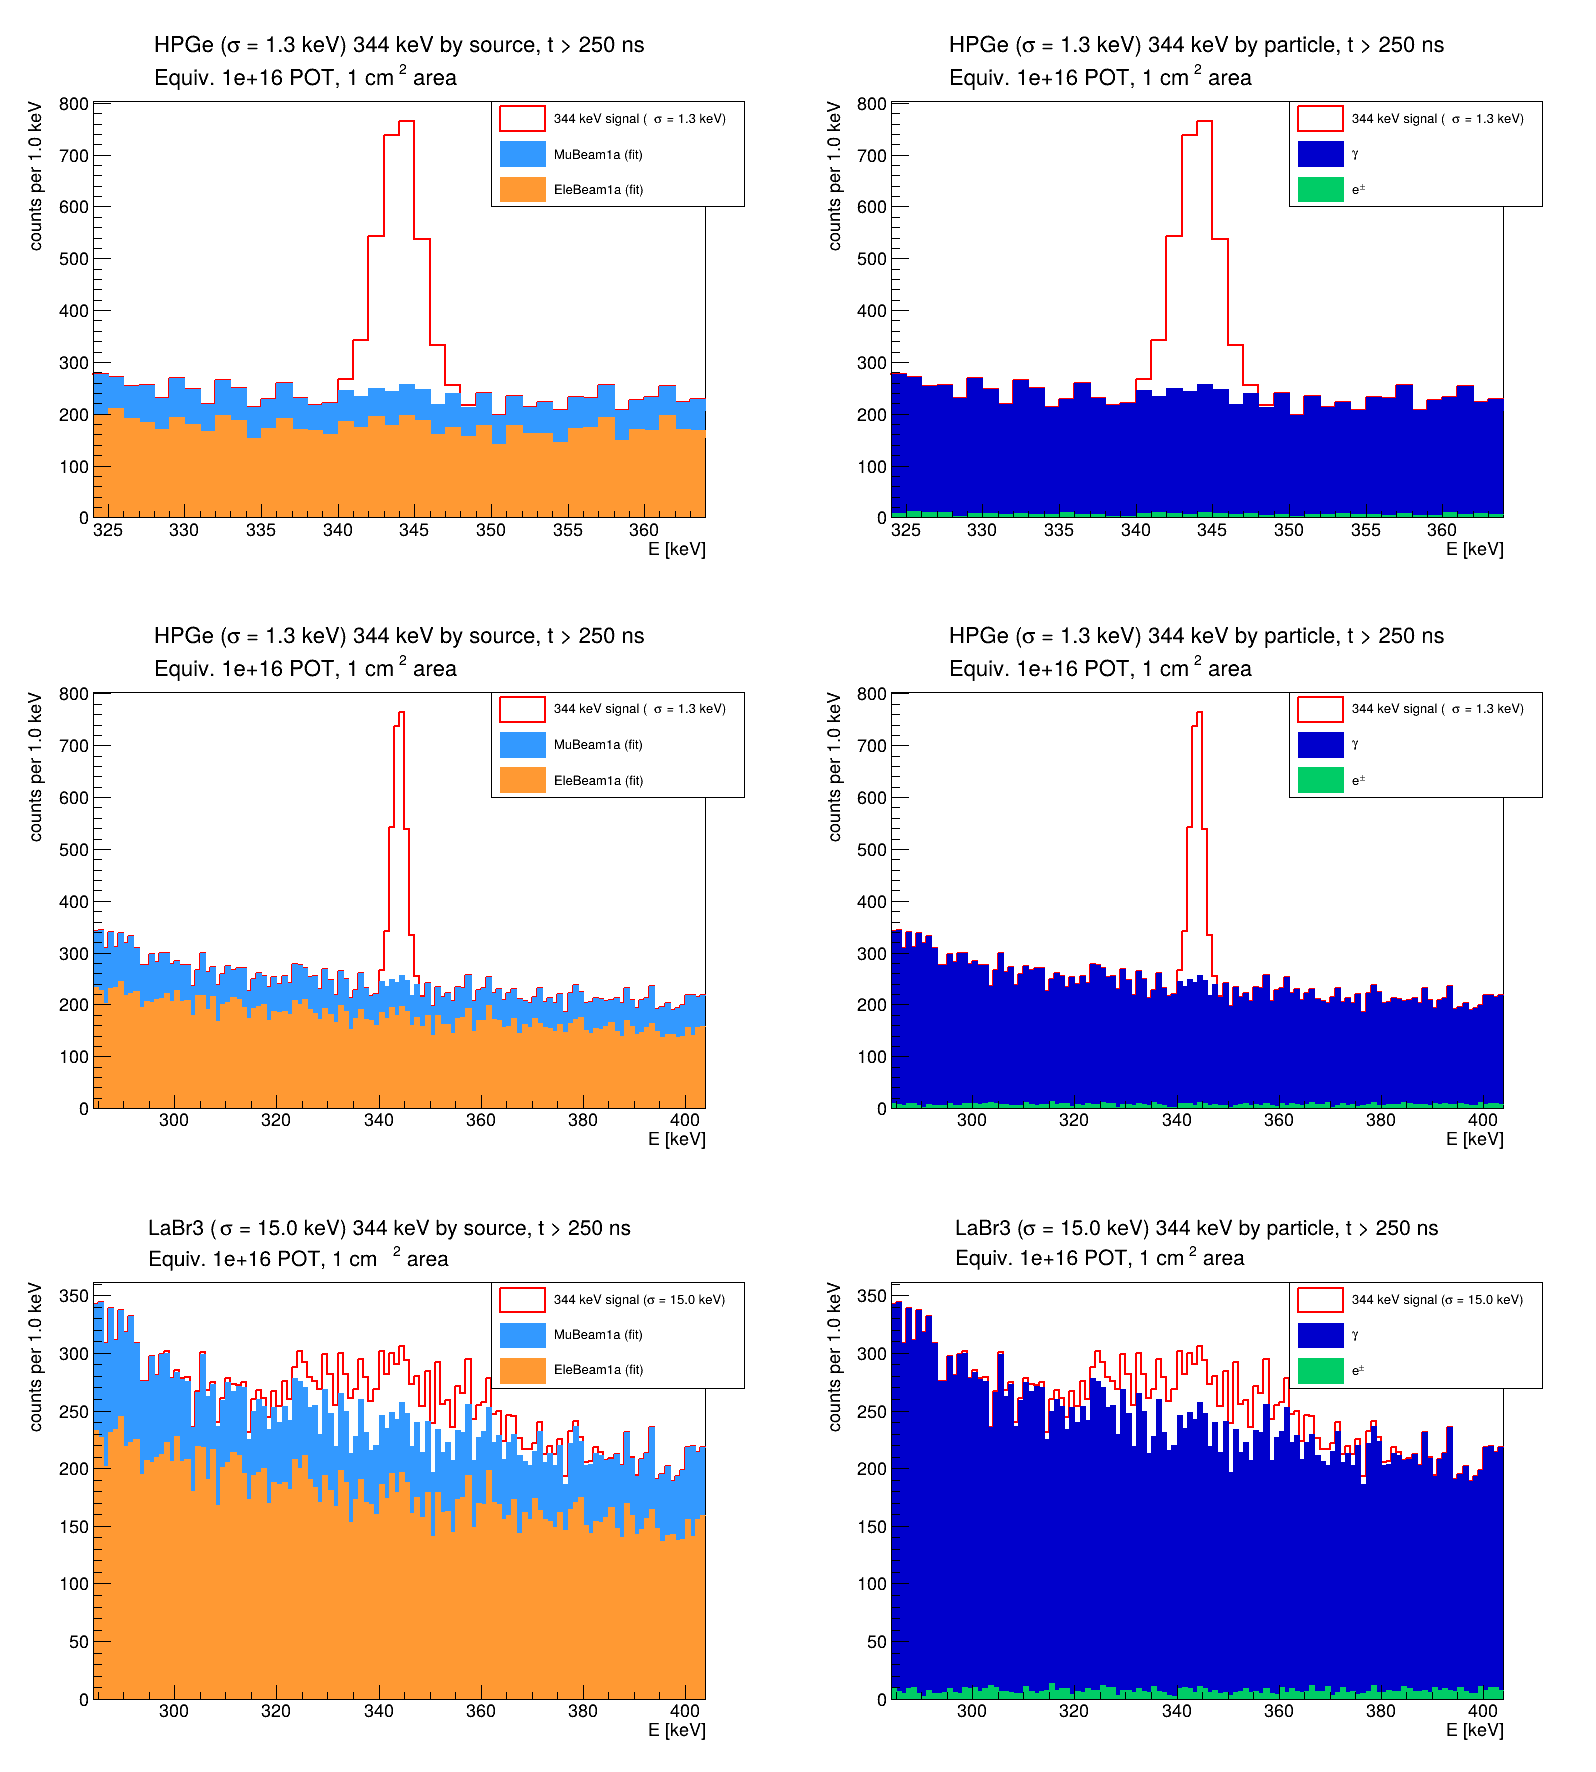

In [9]:
# ---- 344 keV, t > 250 ns: MuBeam1a from local continuum fits, signal added back smeared ----
# The gamma continuum was fit with the 334-335 excess bin masked, so the peak is absent from
# the background by construction -- nothing is subtracted. The excess returns only as the
# smeared signal on top. EleBeam1a comes from the global fits as elsewhere.
# MuBeam1a e+/- has no MC entries in 284-404 keV under the time cut, so it has no local fit
# and contributes zero here -- see mu_local, which holds only the photon group.

tsel_sig = "tcut"
mu_weight = event_dict["MuBeam1a"]["weight"]
mu_groups = [g for g in grp_list if g in mu_local]     # photon only, as things stand

def mu_from_local(name, group_name, color, rng_l):
    """MuBeam1a continuum from the local 284-404 keV fit, on the stack grid."""
    f = mu_local[group_name]
    q0, q1, q2 = f.GetParameter(0), f.GetParameter(1), f.GetParameter(2)
    h = ROOT.TH1D(name, "MuBeam1a %s (local fit);E [keV];counts per %.1f keV"
                  % (group_name, binsize344), nbins344, lo344, hi344)
    h.SetDirectory(0)
    for ib in range(1, nbins344+1):
        # local fit was made per exc_binsize; rescale to the stack bin width
        mu = (np.exp(q0 + q1*h.GetBinCenter(ib)) + q2)*mu_weight*(binsize344/exc_binsize)
        n = rng_l.poisson(max(mu, 0.))
        h.SetBinContent(ib, n)
        h.SetBinError(ib, np.sqrt(n))
    h.SetFillColor(color)
    h.SetLineColor(color)
    return h

def empty_like_stack(name, color):
    """Zero-content component, for a group with no MC entries in this window."""
    h = ROOT.TH1D(name, ";E [keV];counts per %.1f keV" % binsize344,
                  nbins344, lo344, hi344)
    h.SetDirectory(0)
    h.SetFillColor(color)
    h.SetLineColor(color)
    return h

rng_f = np.random.default_rng(31415)
mu_grp = {}
for g in grp_list:
    if g in mu_local:
        mu_grp[g] = mu_from_local("h_fin_mu_%s" % g, g, grp_colors[g], rng_f)
    else:
        mu_grp[g] = empty_like_stack("h_fin_mu_%s" % g, grp_colors[g])
        print("MuBeam1a %s: no local fit (no MC entries in window), contributing zero" % g)

h_mu = mu_grp[mu_groups[0]].Clone("h_fin_MuBeam1a")
h_mu.SetDirectory(0)
for g in mu_groups[1:]:
    h_mu.Add(mu_grp[g])
h_mu.SetFillColor(tag_colors["MuBeam1a"])
h_mu.SetLineColor(tag_colors["MuBeam1a"])
print("MuBeam1a from local fit, weighted: %.4g" % h_mu.Integral())

# ---- EleBeam1a, one set of throws used by both decompositions ----
# Generated per group here, then summed for the by-source component, so the two panels
# are the same events counted two ways rather than two independent Poisson realizations.
rng_e = np.random.default_rng(27182)
ele_grp_fin = {g: ele_from_fit344("h_fin_ele_%s" % g, g, tsel_sig, grp_colors[g], rng_e)
               for g in grp_list}

h_ele_fin = ele_grp_fin[grp_list[0]].Clone("h_fin_EleBeam1a")
h_ele_fin.SetDirectory(0)
for g in grp_list[1:]:
    h_ele_fin.Add(ele_grp_fin[g])
h_ele_fin.SetFillColor(tag_colors["EleBeam1a"])
h_ele_fin.SetLineColor(tag_colors["EleBeam1a"])

fin_bytag = {"MuBeam1a": h_mu,
             "EleBeam1a": h_ele_fin}

fin_bygrp = {}
for g in grp_list:
    h = mu_grp[g].Clone("h_fin_grp_%s" % g)
    h.SetDirectory(0)
    h.Add(ele_grp_fin[g])
    h.SetFillColor(grp_colors[g])
    h.SetLineColor(grp_colors[g])
    fin_bygrp[g] = h
    print("%-8s total weighted: %.4g" % (g, h.Integral()))

sig_by_det = {det: regrid(h_smeared[det], "h_fin_sig_%s" % det, ROOT.kRed)
              for det in ("HPGe", "LaBr3")}
for det in ("HPGe", "LaBr3"):
    print("%-6s signal on grid: %.4g of %.4g"
          % (det, sig_by_det[det].Integral(), h_smeared[det].Integral()))

# ---- draw: rows = detector, cols = by source / by particle ----
cFin = ROOT.TCanvas("cFin", "cFin", 1600, 1800)
cFin.Divide(2, 3)
keepFin = []
ipad = 0

for ii, det, sigma in ((0, "HPGe", E_sigma), (1, "HPGe", E_sigma), (2, "LaBr3", labr_sigma)):
    sig = sig_by_det[det]
    slabel = "344 keV signal (#sigma = %.1f keV)" % sigma

    ipad += 1
    thispad = cFin.cd(ipad)
    thispad.SetTopMargin(0.15)
    hs = ROOT.THStack("hs_fin_tag_%s" % det,
                      "#splitline{%s (#sigma = %.1f keV) 344 keV by source, t > 250 ns}{Equiv. %.2g POT, 1 cm{}^{2} area};E [keV];counts per %.1f keV"
                      % (det, sigma, nNorm, binsize344))
    for tag in stack_order:
        hs.Add(fin_bytag[tag])
    hs.Add(sig)
    if ii == 0: 
        hs.SetHistogram(hdummy)
    hs.Draw("hist")
    leg = ROOT.TLegend(0.62, 0.66, 0.95, 0.85)
    leg.AddEntry(sig, slabel, "f")
    for tag in reversed(stack_order):
        leg.AddEntry(fin_bytag[tag], tag + " (fit)", "f")
    leg.Draw()
    keepFin += [hs, leg]

    ipad += 1
    thispad = cFin.cd(ipad)
    thispad.SetTopMargin(0.15)
    hsg = ROOT.THStack("hs_fin_grp_%s" % det,
                       "#splitline{%s (#sigma = %.1f keV) 344 keV by particle, t > 250 ns}{Equiv. %.2g POT, 1 cm{}^{2} area};E [keV];counts per %.1f keV"
                       % (det, sigma, nNorm, binsize344))
    for g in grp_list:
        hsg.Add(fin_bygrp[g])
    hsg.Add(sig)
    if ii == 0: 
        hsg.SetHistogram(hdummy)
    hsg.Draw("hist")
    legg = ROOT.TLegend(0.62, 0.66, 0.95, 0.85)
    legg.AddEntry(sig, slabel, "f")
    for g in reversed(grp_list):
        legg.AddEntry(fin_bygrp[g], grp_names[g], "f")
    legg.Draw()
    keepFin += [hsg, legg]

cFin.Draw()

for det, sigma in (("HPGe", E_sigma), ("LaBr3", labr_sigma)):
    nS = sig_by_det[det].Integral()
    nB = sum(fin_bytag[t].Integral() for t in stack_order)
    nB_grp = sum(fin_bygrp[g].Integral() for g in grp_list)
    print("%-6s: S = %.4g, B = %.4g, S/B = %.4g, S/sqrt(B) = %.4g"
          % (det, nS, nB, nS/nB if nB > 0 else np.inf, nS/np.sqrt(nB) if nB > 0 else np.inf))
    print("        cross-check: B by source = %.6g, B by particle = %.6g" % (nB, nB_grp))
